In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds



In [3]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lon= slice(110, 260), lat = slice(20, -20))

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(20, -20), lon= slice(110, 260))



In [4]:
dsst = (sst.sel(time = slice('2023-01', '2023-12')).mean(['time'])-sst.sel(time = slice('2022-01', '2022-12')).mean(['time']))
w = w500.sel(time = slice('2023-01', '2023-12')).mean(['time'])





In [6]:
# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values23 = dsst['sst'].values
w_values23 = w['w'].values


# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values23) & ~np.isnan(w_values23)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values23 = dsst_values23[valid_mask]
w_values23 = w_values23[valid_mask]*(24*3600/100)


In [7]:
dsst = (sst.sel(time = slice('2015-01', '2015-12')).mean(['time'])-sst.sel(time = slice('2014-01', '2014-12')).mean(['time']))
w = w500.sel(time = slice('2015-{}'.format(1), '2015-{}'.format(12))).mean(['time'])





In [8]:
# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values15 = dsst['sst'].values
w_values15 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values15) & ~np.isnan(w_values15)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values15 = dsst_values15[valid_mask]
w_values15 = w_values15[valid_mask]*(24*3600/100)


In [9]:
dsst = (sst.sel(time = slice('2009-01', '2009-12')).mean(['time'])-sst.sel(time = slice('2008-01', '2008-12')).mean(['time']))
w = w500.sel(time = slice('2009-{}'.format(1), '2009-{}'.format(12))).mean(['time'])





In [10]:
# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values09 = dsst['sst'].values
w_values09 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values09) & ~np.isnan(w_values09)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values09 = dsst_values09[valid_mask]
w_values09 = w_values09[valid_mask]*(24*3600/100)


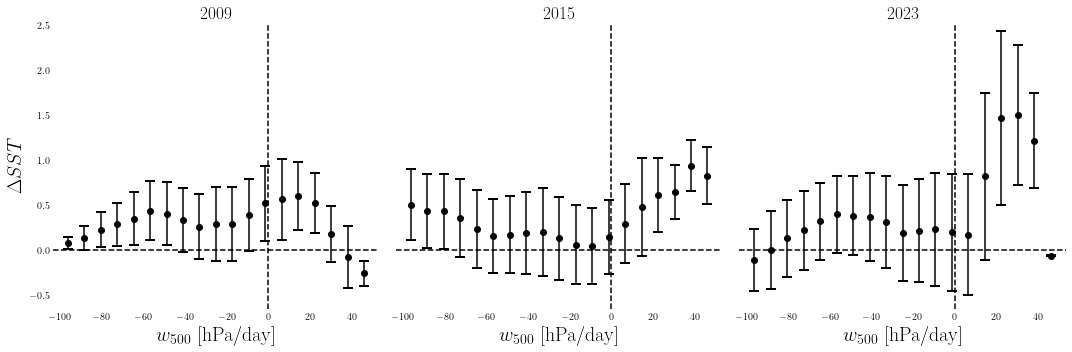

In [11]:
# Set the rc parameters for LaTeX
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# Variable to control the fontsize of the axis labels
fontsize = 20

# Create a figure with three subplots arranged horizontally and sharing the y-axis
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Define the bins for w
w_bins = np.linspace(-100, 50, num=20)

# Plot for 2009 data
w_digitized = np.digitize(w_values09, bins=w_bins)
dsst_means = [dsst_values09[w_digitized == i].mean() for i in range(1, len(w_bins))]
dsst_stds = [dsst_values09[w_digitized == i].std() for i in range(1, len(w_bins))]
bin_centers = (w_bins[:-1] + w_bins[1:]) / 2

axes[0].errorbar(bin_centers, dsst_means, yerr=dsst_stds, fmt='o', capsize=5, capthick=2, color='k', label='2009')
axes[0].set_xlabel(r'$w_{500}$ [hPa/day]', fontsize=fontsize)
axes[0].set_ylabel(r'$\Delta SST$', fontsize=fontsize)
axes[0].axhline(0, c='k', linestyle='--')
axes[0].axvline(0, c='k', linestyle='--')
axes[0].set_title('2009')
axes[0].tick_params(axis='both', which='both', length=0)

# Plot for 2015 data
w_digitized = np.digitize(w_values15, bins=w_bins)
dsst_means = [dsst_values15[w_digitized == i].mean() for i in range(1, len(w_bins))]
dsst_stds = [dsst_values15[w_digitized == i].std() for i in range(1, len(w_bins))]
bin_centers = (w_bins[:-1] + w_bins[1:]) / 2

axes[1].errorbar(bin_centers, dsst_means, yerr=dsst_stds, fmt='o', capsize=5, capthick=2, color='k', label='2015')
axes[1].set_xlabel(r'$w_{500}$ [hPa/day]', fontsize=fontsize)
axes[1].axhline(0, c='k', linestyle='--')
axes[1].axvline(0, c='k', linestyle='--')
axes[1].set_title('2015')
axes[1].tick_params(axis='both', which='both', length=0)

# Plot for 2023 data
w_digitized = np.digitize(w_values23, bins=w_bins)
dsst_means = [dsst_values23[w_digitized == i].mean() for i in range(1, len(w_bins))]
dsst_stds = [dsst_values23[w_digitized == i].std() for i in range(1, len(w_bins))]
bin_centers = (w_bins[:-1] + w_bins[1:]) / 2

axes[2].errorbar(bin_centers, dsst_means, yerr=dsst_stds, fmt='o', capsize=5, capthick=2, color= 'k')
axes[2].set_xlabel(r'$w_{500}$ [hPa/day]', fontsize=fontsize)
axes[2].axhline(0, c='k', linestyle='--')
axes[2].axvline(0, c='k', linestyle='--')
axes[2].set_title('2023')
axes[2].tick_params(axis='both', which='both', length=0)

# Make the axis box (spines) invisible
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

# Set the upper limit of the y-axis
axes[0].set_ylim(top=2.5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()


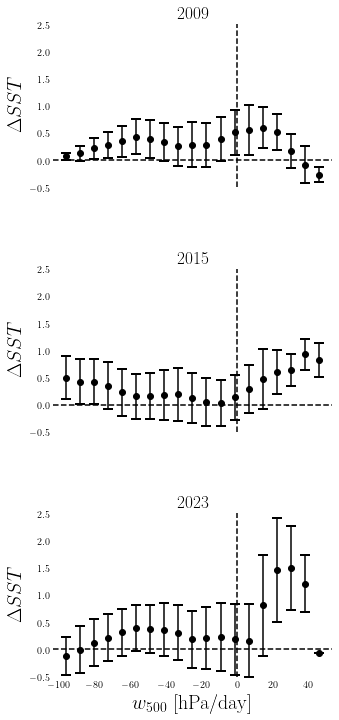

In [25]:
# Set the rc parameters for LaTeX
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# Variable to control the fontsize of the axis labels
fontsize = 20

# Create a figure with three subplots arranged horizontally and sharing the y-axis
fig, axes = plt.subplots(3, 1, figsize=(5, 12), sharex=True)

# Define the bins for w
w_bins = np.linspace(-100, 50, num=20)

# Plot for 2009 data
w_digitized = np.digitize(w_values09, bins=w_bins)
dsst_means = [dsst_values09[w_digitized == i].mean() for i in range(1, len(w_bins))]
dsst_stds = [dsst_values09[w_digitized == i].std() for i in range(1, len(w_bins))]
bin_centers = (w_bins[:-1] + w_bins[1:]) / 2

axes[0].errorbar(bin_centers, dsst_means, yerr=dsst_stds, fmt='o', capsize=5, capthick=2, color='k', label='2009')
#axes[0].set_xlabel(r'$w_{500}$ [hPa/day]', fontsize=fontsize)
axes[0].set_ylabel(r'$\Delta SST$', fontsize=fontsize)
axes[0].axhline(0, c='k', linestyle='--')
axes[0].axvline(0, c='k', linestyle='--')
axes[0].set_title('2009')
axes[0].tick_params(axis='both', which='both', length=0)

# Plot for 2015 data
w_digitized = np.digitize(w_values15, bins=w_bins)
dsst_means = [dsst_values15[w_digitized == i].mean() for i in range(1, len(w_bins))]
dsst_stds = [dsst_values15[w_digitized == i].std() for i in range(1, len(w_bins))]
bin_centers = (w_bins[:-1] + w_bins[1:]) / 2

axes[1].errorbar(bin_centers, dsst_means, yerr=dsst_stds, fmt='o', capsize=5, capthick=2, color='k', label='2015')
#axes[1].set_xlabel(r'$w_{500}$ [hPa/day]', fontsize=fontsize)
axes[1].set_ylabel(r'$\Delta SST$', fontsize=fontsize)

axes[1].axhline(0, c='k', linestyle='--')
axes[1].axvline(0, c='k', linestyle='--')
axes[1].set_title('2015')
axes[1].tick_params(axis='both', which='both', length=0)

# Plot for 2023 data
w_digitized = np.digitize(w_values23, bins=w_bins)
dsst_means = [dsst_values23[w_digitized == i].mean() for i in range(1, len(w_bins))]
dsst_stds = [dsst_values23[w_digitized == i].std() for i in range(1, len(w_bins))]
bin_centers = (w_bins[:-1] + w_bins[1:]) / 2

axes[2].errorbar(bin_centers, dsst_means, yerr=dsst_stds, fmt='o', capsize=5, capthick=2, color= 'k')
axes[2].set_xlabel(r'$w_{500}$ [hPa/day]', fontsize=fontsize)
axes[2].set_ylabel(r'$\Delta SST$', fontsize=fontsize)

axes[2].axhline(0, c='k', linestyle='--')
axes[2].axvline(0, c='k', linestyle='--')
axes[2].set_title('2023')
axes[2].tick_params(axis='both', which='both', length=0)

# Make the axis box (spines) invisible
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

# Set the upper limit of the y-axis
axes[0].set_ylim(-0.5,2.5)
axes[1].set_ylim(-0.5,2.5)
axes[2].set_ylim(-0.5,2.5)

# Adjust layout to prevent overlap
#plt.tight_layout()

plt.subplots_adjust(hspace=0.5)


# Display the plot
plt.show()


In [12]:
dsst = (sst.sel(time = slice('2015-01', '2015-12')).mean(['time'])-sst.sel(time = slice('2014-01', '2014-12')).mean(['time']))
w = w500.sel(time = slice('2015-{}'.format(1), '2015-{}'.format(12))).mean(['time'])





In [13]:
dsst = (sst.sel(time = slice('1998-01', '1998-12')).mean(['time'])-sst.sel(time = slice('1997-01', '1997-12')).mean(['time']))
w = w500.sel(time = slice('1998-{}'.format(1), '1998-{}'.format(12))).mean(['time'])





In [14]:
plt.rc('text', usetex=True)


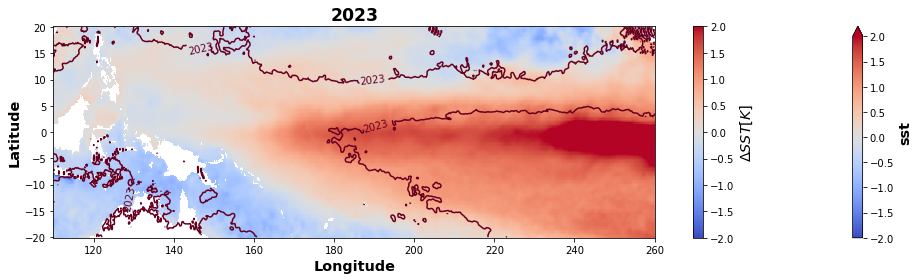

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

# Plot the SST data
cbar = (sst.sel(time=slice('2023-01', '2023-12')).mean(['time']).sst - sst.sel(time=slice('2022-01', '2022-12')).mean(['time']).sst).plot(
    cmap='coolwarm', vmin=-2, vmax=2, ax=ax)

# Plot the contour
CS1 = w500.sel(time=slice('2023-{}'.format(1), '2023-{}'.format(12))).mean(['time']).w.plot.contour(levels=[-0.0], ax=ax)
#CS = w500.sel(time=slice('2022-{}'.format(1), '2022-{}'.format(12))).mean(['time']).w.plot.contour(levels=[-0.0], ax=ax, colors = 'white')

ax.set_title('2023')
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
#ax.clabel(CS, CS.levels, inline=True, fmt={0:'2022'}, fontsize=10)
ax.clabel(CS1, CS1.levels, inline=True, fmt={0:'2023'}, fontsize=10)

# Add the colorbar with label
plt.colorbar(cbar, label=r'$\Delta SST [K]$')

plt.tight_layout()
plt.show()


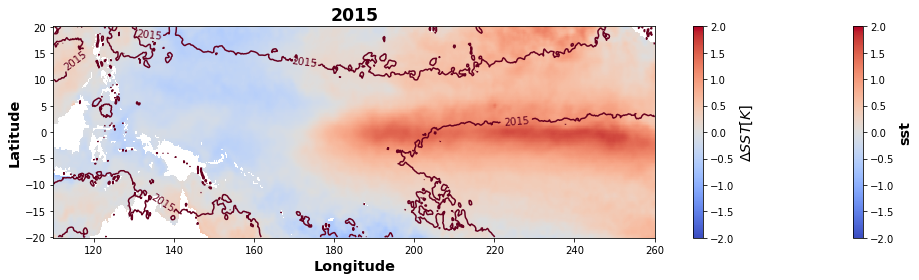

In [12]:
fig, ax = plt.subplots(1,1, figsize = (14,4))

cbar = (sst.sel(time = slice('2015-01', '2015-12')).mean(['time'])-sst.sel(time = slice('2014-01', '2014-12')).mean(['time'])).sst.plot(
    cmap = 'coolwarm', vmin = -2, vmax = 2)

CS1 = w500.sel(time = slice('2015-01', '2015-12')).mean(['time']).w.plot.contour(levels = [-0.0])
#CS = w500.sel(time = slice('2014-01', '2014-12')).mean(['time']).w.plot.contour(levels = [-0.0], colors = 'white')
ax.set_title('2015')
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
#ax.clabel(CS, CS.levels, inline=True, fmt={0:'2014'}, fontsize=10)
ax.clabel(CS1, CS1.levels, inline=True, fmt={0:'2015'}, fontsize=10)



# Add the colorbar with label
plt.colorbar(cbar, label=r'$\Delta SST [K]$')

plt.tight_layout()
plt.show()

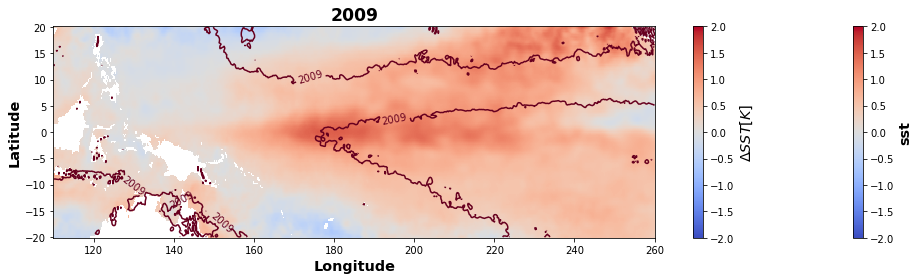

In [10]:
fig, ax = plt.subplots(1,1, figsize = (14,4))

cbar =  (sst.sel(time = slice('2009-01', '2009-12')).mean(['time'])-sst.sel(time = slice('2008-01', '2008-12')).mean(['time'])).sst.plot(
    cmap = 'coolwarm', vmin = -2, vmax = 2)

CS1 = w500.sel(time = slice('2009-01', '2009-12')).mean(['time']).w.plot.contour(levels = [-0.0])
#CS = w500.sel(time = slice('2008-01', '2008-12')).mean(['time']).w.plot.contour(levels = [-0.0], colors = 'white', add_labels = True)
ax.set_title('2009')
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')


#ax.clabel(CS, CS.levels, inline=True, fmt={0:'2008'}, fontsize=10)
ax.clabel(CS1, CS1.levels, inline=True, fmt={0:'2009'}, fontsize=10)




# Add the colorbar with label
plt.colorbar(cbar, label=r'$\Delta SST [K]$')

plt.tight_layout()
plt.show()

In [19]:
fig, ax = plt.subplots(1,1, figsize = (12,4))

(sst.sel(time = slice('1997-01', '1997-12')).mean(['time'])-sst.sel(time = slice('1996-01', '1996-12')).mean(['time'])).sst.plot(
    cmap = 'coolwarm', vmin = -2, vmax = 2)

w500.sel(time = slice('1997-01', '1997-12')).mean(['time']).w.plot.contour(levels = [-0.0])
#w500.sel(time = slice('1996-01', '1996-12')).mean(['time']).w.plot.contour(levels = [-0.0], colors = 'white')

RuntimeError: latex was not able to process the following string:
b'Longitude [degrees_east]'

Here is the full report generated by latex:
This is pdfTeX, Version 3.14159265-2.6-1.40.20 (TeX Live 2019/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(/home/jmex/.cache/matplotlib/tex.cache/49b44a8d34d5f4c89b8e3bdcd4146a0f.tex
LaTeX2e <2020-02-02> patch level 2
L3 programming layer <2020-02-14>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2019/12/20 v1.4l Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/share/texlive/texmf-dist/tex/latex/graphics/keyval.sty)
(/usr/share/texlive/texmf-

<Figure size 864x288 with 2 Axes>

# fig, ax = plt.subplots(1,1, figsize = (12,4))

(sst.sel(time = slice('2009-01', '2009-12')).mean(['time'])-sst.sel(time = slice('2008-01', '2008-12')).mean(['time'])).sst.plot(
    cmap = 'coolwarm', vmin = -2, vmax = 2)

w500.sel(time = slice('2009-01', '2009-12')).mean(['time']).w.plot.contour(levels = [-0.0])
w500.sel(time = slice('2009-01', '2009-12')).mean(['time']).w.plot.contour(levels = [-0.0])

In [28]:
w500.roll(time = 1)-w500

<xarray.Dataset>
Dimensions:  (time: 890, lon: 681, lat: 161)
Coordinates:
  * time     (time) datetime64[ns] 1950-01-01 1950-02-01 ... 2024-02-01
  * lon      (lon) float32 110.0 110.2 110.5 110.8 ... 279.2 279.5 279.8 280.0
  * lat      (lat) float32 20.0 19.75 19.5 19.25 ... -19.25 -19.5 -19.75 -20.0
Data variables:
    w        (time, lat, lon) float32 -0.03549 -0.04221 ... -0.01058 -0.01406

In [40]:
20* 100/(24*3600)

0.023148148148148147